In [68]:
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory

# ====================================================
# 1. Global config
# ====================================================
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 123

root_dir = Path("chest_xray")
train_dir = root_dir / "train"   # contains: NORMAL, bacteria, virus
test_dir  = root_dir / "test"    # contains: NORMAL, bacteria, virus

AUTOTUNE = tf.data.AUTOTUNE

In [69]:
# ====================================================
# 2. Preprocess + prepare helper
# ====================================================
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def prepare(ds, shuffle=False, repeat=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    if repeat:
        ds = ds.repeat()
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds



In [70]:

# Unbatched train set for manual train/val split
train_ds_raw = image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    seed=SEED,
    batch_size=None,
)

test_ds_raw = image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    seed=SEED,
    batch_size=None,
)

class_names = train_ds_raw.class_names  # ['NORMAL', 'bacteria', 'virus']
print("Classes:", class_names)

Found 5232 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


In [71]:

# Train/validation split
total     = train_ds_raw.cardinality().numpy()
val_size  = int(0.1 * total)
train_size = total - val_size

train_ds = train_ds_raw.take(train_size)
val_ds   = train_ds_raw.skip(train_size)

# --- 3‑class subsets ---
total_train = train_ds.cardinality().numpy()

def make_subset(fraction):
    n = int(total * fraction)
    subset_raw = train_ds.take(n)
    return prepare(subset_raw, shuffle=True)

train_10  = make_subset(0.10)
train_25  = make_subset(0.25)
train_50  = make_subset(0.50)
train_100 = prepare(train_ds, shuffle=True)

val  = prepare(val_ds, shuffle=False, repeat=False)
test = prepare(test_ds_raw,shuffle=False, repeat=False)

val_steps = max(1, val_ds.cardinality().numpy() // BATCH_SIZE)
val   = prepare(val_ds,   shuffle=False, repeat=False)
test  = prepare(test_ds_raw, shuffle=False, repeat=False)

for xb, yb in test.take(1):
    print("test batch shapes:", xb.shape, yb.shape)



test batch shapes: (32, 224, 224, 3) (32,)


In [72]:
# ====================================================
# 5. Shared model definition: MobileNetV2 from scratch
# ====================================================
def make_backbone():
    return tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights=None,        # or "imagenet" if you want transfer learning
        pooling="avg",
    )

def make_classifier(backbone=None):
    if backbone is None:
        backbone = make_backbone()
    inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = backbone(inputs, training=True)
    outputs = layers.Dense(3, activation="softmax")(x)  # 3 classes
    model   = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


backbone = make_backbone()
model    = make_classifier(backbone)
model.summary()


Model: "model_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_37 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 1280)             2257984   
 ional)                                                          
                                                                 
 dense_17 (Dense)            (None, 3)                 3843      
                                                                 
Total params: 2,261,827
Trainable params: 2,227,715
Non-trainable params: 34,112
_________________________________________________________________


In [73]:
from collections import OrderedDict

# ====================================================
# Train 3‑class Model (NORMAL / bacteria / virus)
# ====================================================
EPOCHS = 20
subsets = {
    "10%": train_10,
    "25%": train_25,
    "50%": train_50,
    "100%": train_100,
}

histories = {}
tests     = {}
models_3  = OrderedDict() 

for name, train_ds in subsets.items():
    print(f"\n=== 3‑class training on {name} of pool ===")
    model = make_classifier()
    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val
    )
    histories[name] = history.history
    tests[name]     = model.evaluate(test, return_dict=True)
    models_3[name]  = model

print("3‑class test metrics per subset:", tests)


=== 3‑class training on 10% of pool ===
Epoch 1/20
17/17 [==============================] - 29s 641ms/step - loss: 0.4631 - accuracy: 0.7973 - val_loss: 0.3730 - val_accuracy: 0.8394
Epoch 2/20
17/17 [==============================] - 12s 600ms/step - loss: 0.3379 - accuracy: 0.8853 - val_loss: 0.3570 - val_accuracy: 0.8375
Epoch 3/20
17/17 [==============================] - 12s 604ms/step - loss: 0.2326 - accuracy: 0.9025 - val_loss: 0.2810 - val_accuracy: 0.8757
Epoch 4/20
17/17 [==============================] - 12s 594ms/step - loss: 0.2118 - accuracy: 0.9082 - val_loss: 0.2724 - val_accuracy: 0.8948
Epoch 5/20
17/17 [==============================] - 12s 592ms/step - loss: 0.2352 - accuracy: 0.9006 - val_loss: 0.2533 - val_accuracy: 0.8815
Epoch 6/20
17/17 [==============================] - 12s 594ms/step - loss: 0.1945 - accuracy: 0.9312 - val_loss: 0.2452 - val_accuracy: 0.9140
Epoch 7/20
17/17 [==============================] - 12s 591ms/step - loss: 0.1348 - accuracy: 0.9465 

82/82 [==============================] - 17s 160ms/step - loss: 0.0217 - accuracy: 0.9927 - val_loss: 0.0899 - val_accuracy: 0.9694
Epoch 17/20
82/82 [==============================] - 17s 163ms/step - loss: 0.0321 - accuracy: 0.9912 - val_loss: 0.1671 - val_accuracy: 0.9465
Epoch 18/20
82/82 [==============================] - 17s 161ms/step - loss: 0.0486 - accuracy: 0.9843 - val_loss: 0.1035 - val_accuracy: 0.9675
Epoch 19/20
82/82 [==============================] - 17s 162ms/step - loss: 0.0468 - accuracy: 0.9847 - val_loss: 0.1179 - val_accuracy: 0.9618
Epoch 20/20
20/20 [==============================] - 1s 41ms/step - loss: 3.8131 - accuracy: 0.6458

=== 3‑class training on 100% of pool ===
Epoch 1/20
148/148 [==============================] - 37s 120ms/step - loss: 0.2624 - accuracy: 0.8968 - val_loss: 0.1665 - val_accuracy: 0.9254
Epoch 2/20
148/148 [==============================] - 20s 113ms/step - loss: 0.1457 - accuracy: 0.9471 - val_loss: 0.0836 - val_accuracy: 0.9694
Epoc

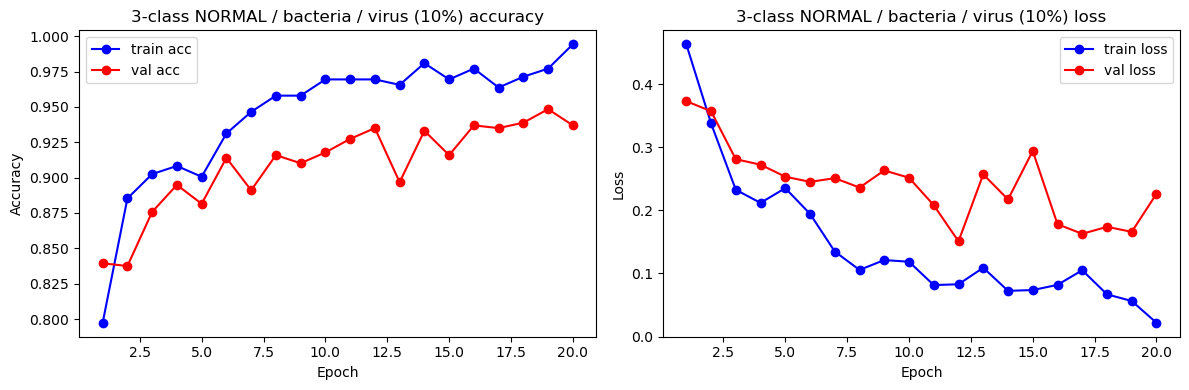

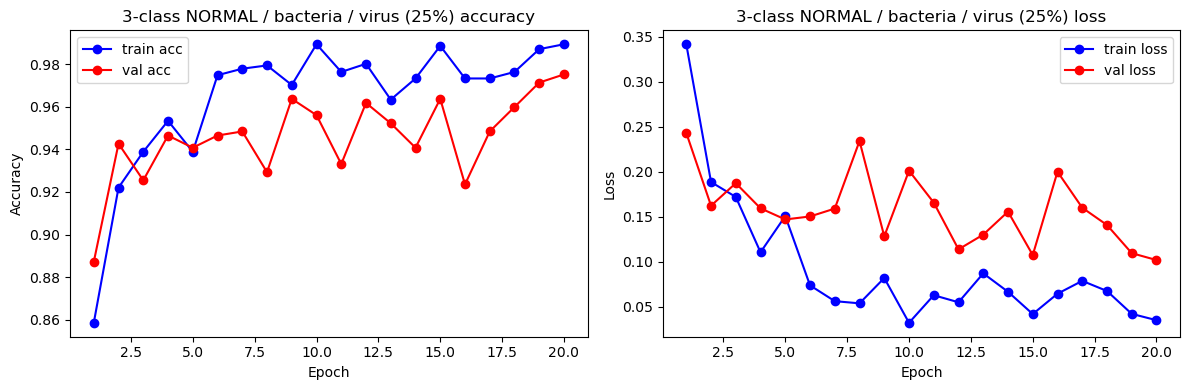

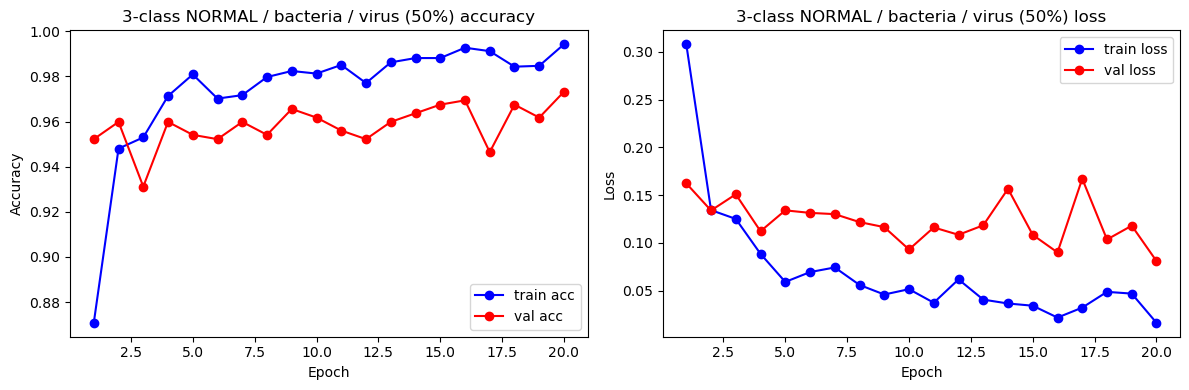

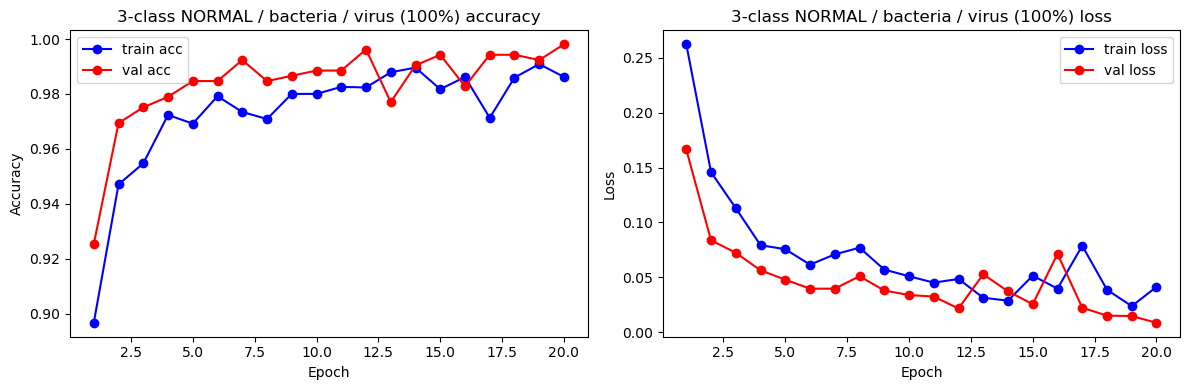

In [76]:
import matplotlib.pyplot as plt

# ====================================================
# Plot histories for all 3‑class subsets
# ====================================================
class HistoryWrapper:
    def __init__(self, hist_dict):
        self.history = hist_dict

def plot_history(history, title_prefix="Model"):
    acc = history.history.get("accuracy", [])
    val_acc = history.history.get("val_accuracy", [])
    loss = history.history.get("loss", [])
    val_loss = history.history.get("val_loss", [])

    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    if len(acc) > 0:
        epochs_acc = range(1, len(acc) + 1)
        plt.plot(epochs_acc, acc, "bo-", label="train acc")
    if len(val_acc) > 0:
        epochs_val_acc = range(1, len(val_acc) + 1)
        plt.plot(epochs_val_acc, val_acc, "ro-", label="val acc")
    plt.title(f"{title_prefix} accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    if len(loss) > 0:
        epochs_loss = range(1, len(loss) + 1)
        plt.plot(epochs_loss, loss, "bo-", label="train loss")
    if len(val_loss) > 0:
        epochs_val_loss = range(1, len(val_loss) + 1)
        plt.plot(epochs_val_loss, val_loss, "ro-", label="val loss")
    plt.title(f"{title_prefix} loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

# plot all 3‑class subset runs
for frac, hist_dict in histories.items():
    plot_history(
        HistoryWrapper(hist_dict),
        title_prefix=f"3‑class NORMAL / bacteria / virus ({frac})"
    )


In [79]:
# true labels (from raw test dataset)
# true labels (from raw test dataset)
y_true_batches = []
for _, labels in test_ds_raw:
    y_true_batches.append(labels.numpy().ravel()) 

y_true = np.concatenate(y_true_batches, axis=0)
class_names = train_ds_raw.class_names  # ['NORMAL', 'bacteria', 'virus']

from sklearn.metrics import classification_report, confusion_matrix

for name, model in models_3.items():
    print(f"\n=== Evaluation on test set – {name} subset ===")
    # predicted probabilities on batched `test`
    probs = model.predict(test)
    y_pred = probs.argmax(axis=1)

    print("Classification report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))



=== Evaluation on test set – 10% subset ===
20/20 [==============================] - 1s 44ms/step
Classification report:
              precision    recall  f1-score   support

      NORMAL       0.46      0.29      0.36       234
   PNEUMONIA       0.65      0.79      0.72       390

    accuracy                           0.61       624
   macro avg       0.56      0.54      0.54       624
weighted avg       0.58      0.61      0.58       624

Confusion matrix:
[[ 69 165]
 [ 81 309]]

=== Evaluation on test set – 25% subset ===
20/20 [==============================] - 1s 44ms/step
Classification report:
              precision    recall  f1-score   support

      NORMAL       0.48      0.22      0.30       234
   PNEUMONIA       0.65      0.86      0.74       390

    accuracy                           0.62       624
   macro avg       0.56      0.54      0.52       624
weighted avg       0.58      0.62      0.57       624

Confusion matrix:
[[ 51 183]
 [ 55 335]]

=== Evaluation on t